# BirdCLEF 2026 — Baseline Training

Trains an EfficientNet-B0 on 5-second mel-spectrogram crops.  
Metric: Macro ROC-AUC | Loss: BCEWithLogitsLoss

In [5]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold

from src.config import load_config, ROOT
from src.dataset import BirdCLEFDataset
from src.models import BirdCLEFModel
from src.train import run_training
from src.utils import seed_everything

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch: 2.10.0
CUDA available: False


## 1. Config & Device

In [6]:
config = load_config('../configs/baseline.yaml')
seed_everything(config['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
print(f'Model   : {config["model_name"]}')
print(f'Epochs  : {config["epochs"]}')
print(f'Batch   : {config["batch_size"]}')
print(f'LR      : {config["lr"]}')

Device  : cpu
Model   : efficientnet_b0
Epochs  : 15
Batch   : 64
LR      : 0.001


## 2. Load Data & Build Splits

In [7]:
df = pd.read_csv(ROOT / config['train_csv'])
df['primary_label'] = df['primary_label'].astype(str)

species_list = sorted(df['primary_label'].unique().tolist())
print(f'Total recordings : {len(df):,}')
print(f'Species          : {len(species_list)}')
print(f'Columns          : {df.columns.tolist()}')
df.head(3)

Total recordings : 35,549
Species          : 206
Columns          : ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=config['seed'])
splits = list(skf.split(df, df['primary_label']))
train_idx, val_idx = splits[config['val_fold']]
print(f'Fold {config["val_fold"]} — train: {len(train_idx):,}  val: {len(val_idx):,}')

audio_dir = ROOT / config['train_audio_dir']
mel_cache_dir = ROOT / config['mel_cache_dir'] if config.get('mel_cache_dir') else None
print(f'Mel cache dir : {mel_cache_dir}')
print(f'Cache exists  : {mel_cache_dir.exists() if mel_cache_dir else False}')

train_ds = BirdCLEFDataset(df.iloc[train_idx], audio_dir, species_list, config, train=True,  mel_cache_dir=mel_cache_dir)
val_ds   = BirdCLEFDataset(df.iloc[val_idx],   audio_dir, species_list, config, train=False, mel_cache_dir=mel_cache_dir)

import time
t = time.time()
_ = train_ds[0]
print(f'Single sample load time: {time.time()-t:.3f}s')

mel, label = train_ds[0]
print(f'Mel shape : {mel.shape}  (channels, mels, time)')
print(f'Label shape : {label.shape}  positive: {label.sum():.0f}')

Fold 0 — train: 28,439  val: 7,110
Mel cache dir : /Users/pravintakpire/datascience/KAGGLE_COMPETITION/BirdCLEF_2026/notebooks/../data/processed/mels
Cache exists  : True
Single sample load time: 0.014s
Mel shape : torch.Size([1, 128, 501])  (channels, mels, time)
Label shape : torch.Size([206])  positive: 1


In [9]:
train_loader = DataLoader(
    train_ds, batch_size=config['batch_size'],
    shuffle=True, num_workers=config['num_workers'], pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=config['batch_size'],
    shuffle=False, num_workers=config['num_workers'], pin_memory=True
)
print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')

Train batches: 445
Val   batches: 112


## 3. Visualise a Training Sample

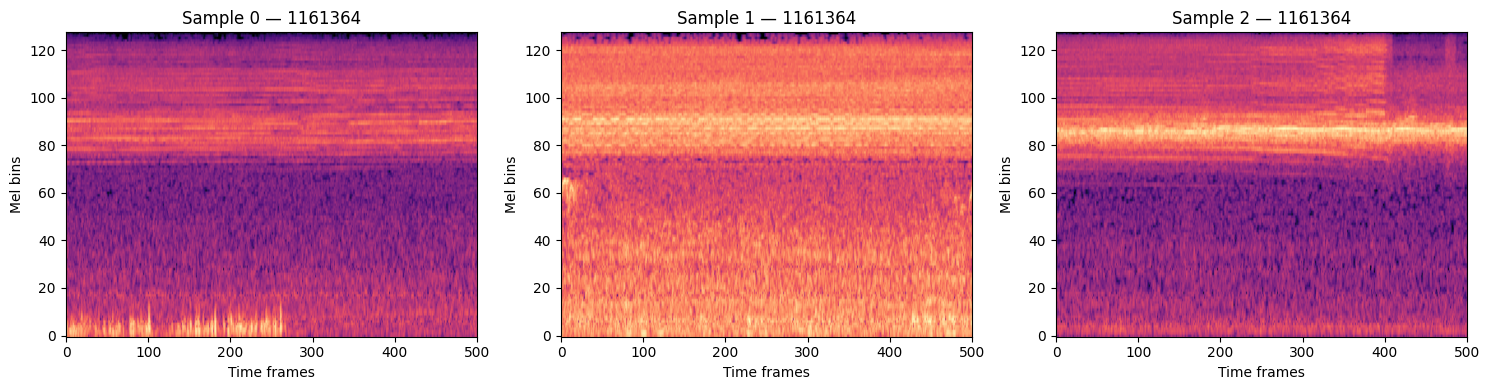

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    mel_i, lbl_i = train_ds[i]
    ax.imshow(mel_i[0].numpy(), origin='lower', aspect='auto', cmap='magma')
    species = species_list[lbl_i.argmax().item()]
    ax.set_title(f'Sample {i} — {species}')
    ax.set_xlabel('Time frames')
    ax.set_ylabel('Mel bins')
plt.tight_layout()
plt.show()

## 4. Build Model

In [11]:
model = BirdCLEFModel(
    num_classes=len(species_list),
    model_name=config['model_name'],
    pretrained=config['pretrained']
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {train_params:,}')

# Verify forward pass
with torch.no_grad():
    dummy = torch.zeros(2, 1, config['n_mels'], 501).to(device)
    out = model(dummy)
print(f'Output shape     : {out.shape}  (batch, num_classes)')

Total params     : 4,270,858
Trainable params : 4,270,858
Output shape     : torch.Size([2, 206])  (batch, num_classes)


## 5. Train

In [ ]:
output_dir = ROOT / config['output_dir']
run_training(model, train_loader, val_loader, config, output_dir, device)

Train:  56%|█████▌    | 249/445 [1:05:56<2:18:16, 42.33s/it]

## 6. Training Curves

In [ ]:
# run_training prints per-epoch lines — parse the captured output if redirected,
# or just load the best checkpoint to confirm it saved.
checkpoint = output_dir / 'best_model.pth'
if checkpoint.exists():
    print(f'Best model saved at: {checkpoint}')
    ckpt = torch.load(checkpoint, map_location='cpu')
    print(f'Checkpoint keys: {len(ckpt)} parameter tensors')
else:
    print('No checkpoint found — training may not have completed.')

## 7. Quick Validation Check

In [ ]:
from src.train import validate
import torch.nn as nn

# Reload best weights
model.load_state_dict(torch.load(output_dir / 'best_model.pth', map_location=device))
criterion = nn.BCEWithLogitsLoss()
val_loss, val_auc = validate(model, val_loader, criterion, device)
print(f'Val Loss : {val_loss:.4f}')
print(f'Val AUC  : {val_auc:.4f}')